In [13]:
import numpy as np
import seaborn
import matplotlib.pyplot as plt
import scipy.stats as stats

experimental_data_1 = np.array([
68, 72, 75, 70, 71, 73, 74, 76, 69, 72,
74, 70, 73, 71, 75, 74, 72, 73, 70, 71,
73, 75, 72, 74, 76, 71, 73, 72, 70, 74
])

experimental_data_2 = np.array([
1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0
])

In [ ]:
# Compute mean p1
mean_p1 = np.mean(experimental_data_1)
print(f"Mean of experimental_data_1: {mean_p1}")

Mean of experimental_data_1: 72.43333333333334


Generated 10000 sample means for null distribution


<Axes: ylabel='Count'>

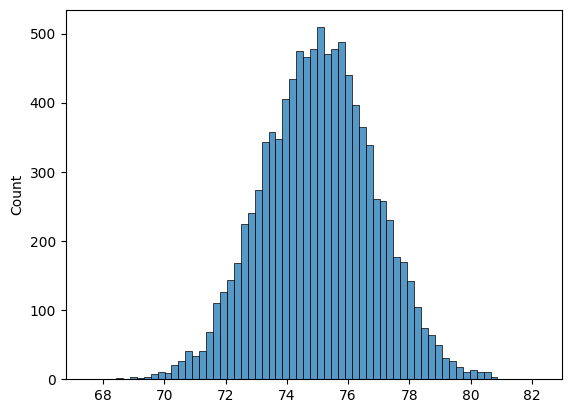

In [25]:
# Normal distribution mean = 75 stdev = 10
normal_data = stats.norm(loc=75, scale=10)

# Generate null distribution by sampling and computing means
null_distribution = []
sample_size = len(experimental_data_1)

for i in range(10000):
    sample = normal_data.ppf(np.random.rand(sample_size))
    sample_mean = np.mean(sample)
    null_distribution.append(sample_mean)

null_distribution = np.array(null_distribution)
print(f"Generated {len(null_distribution)} sample means for null distribution")

seaborn.histplot(null_distribution)

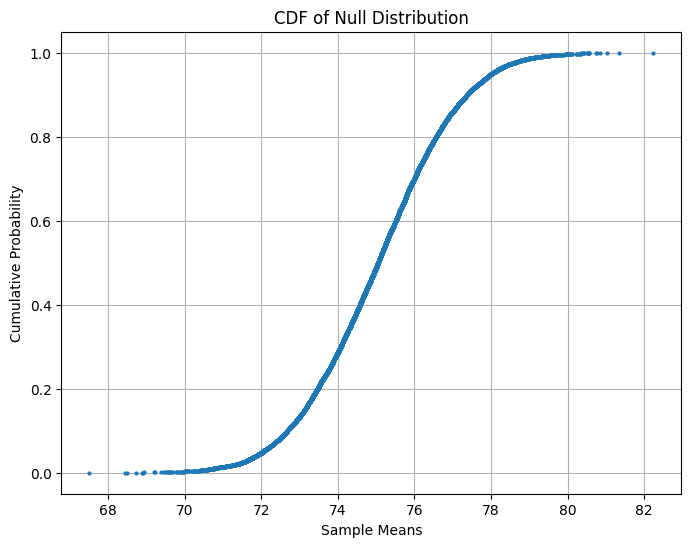

In [26]:
# Create and plot CDF

import matplotlib.pyplot as plt

# Create CDF
sorted_null = np.sort(null_distribution)
y_values = np.arange(1, len(sorted_null) + 1) / len(sorted_null)

# Plot CDF
plt.figure(figsize=(8, 6))
plt.plot(sorted_null, y_values, marker='o', linestyle='none', markersize=2)
plt.xlabel('Sample Means')
plt.ylabel('Cumulative Probability')
plt.title('CDF of Null Distribution')
plt.grid(True)
plt.show()

In [32]:
# Compute p-value
p_value = np.mean(null_distribution >= mean_p1)
print(f"P-value for mean_p1: {p_value}")

P-value for mean_p1: 0.9231


In [33]:
np.mean(experimental_data_2)
print(f"Mean of experimental_data_2: {np.mean(experimental_data_2)}")

Mean of experimental_data_2: 0.81


In [36]:
null_distribution_2 = stats.binom(n=100, p=0.6)

sample_2 = []

for _ in range(10000):
    sample_2.append(null_distribution_2.ppf(np.random.rand()) / 100)

<Axes: ylabel='Count'>

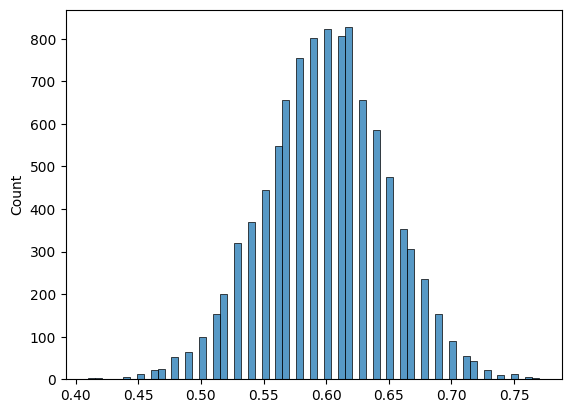

In [37]:
seaborn.histplot(sample_2)

In [38]:
sorted_sample_2 = np.sort(sample_2)
ecdf_2 = np.arange(0, len(sorted_sample_2)) / len(sorted_sample_2)

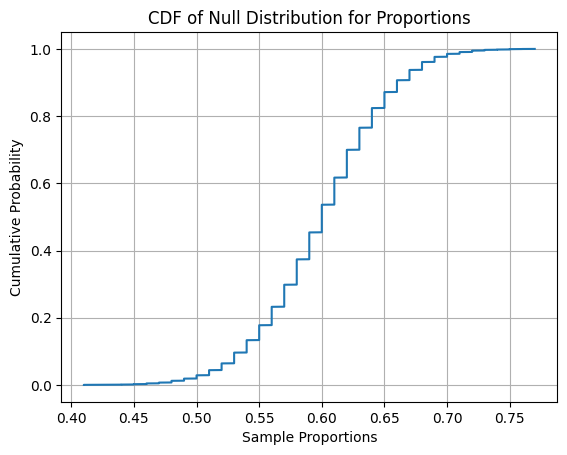

In [40]:
plt.plot(sorted_sample_2, ecdf_2)
plt.xlabel('Sample Proportions')
plt.ylabel('Cumulative Probability')
plt.title('CDF of Null Distribution for Proportions')
plt.grid(True)
plt.show()

In [43]:
right_tail = np.mean(sorted_sample_2 >= np.mean(experimental_data_2))
left_tail = np.mean(sorted_sample_2 <= (0.6 - (np.mean(experimental_data_2) - 0.6)))

p_value = right_tail + left_tail
print(f"P-value for mean_p2: {p_value}")

P-value for mean_p2: 0.0
